# **🏥 Automated Burn Diagnosis Pipeline Assignment**
### *A classification model to distinguish between graft and non-graft cases using the BIP_US database.*

---


#### 🎨 1. Feature Extraction
Extracts LAB color statistics and HoG texture descriptors to mathematically model physical burn characteristics.


In [ ]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

def extract_features(img_path, img_size=(256, 256)):

    #reading the image in RGB
    img_array = cv2.imread(img_path)
    #converting the colors to CIELAB color space
    img_lab = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

    #img_array = cv2.resize(img_array, img_size)
    # (Use the correct method to split the color channels)
    l_channel, a_channel, b_channel = cv2.split(img_lab)
    #are we gonna have the l channel here?

    #
    a_float = a_channel.astype(float) - 128.0
    b_float = b_channel.astype(float) - 128.0

    # Isolate ROI (Region of Interest Masking)
    # (Take a look at the images in the dataset and find how we can isolate/mask the region of interest using the color channels)
    # (Hint: use the library methods at your disposal, such as Numpy)
    #we are trying to extract the roi from the image with the background. the background will have significantly different values in the cielab colorspace.
    #therefore, we only pick the pixels where the conditions below are satisfied.
    roi_mask = ((np.abs(a_float) > 20) | (np.abs(b_float) > 20))

    a_valid = a_float[roi_mask]
    b_valid = b_float[roi_mask]

    # Explicit statistical features calculated on the ROI as defined in the paper
    # (Apply the formulas we have learned or the proper imported methods to extract each feature. Find the mean values using the correct methods where needed)
    mean_a = np.mean(a_valid)
    mean_b = np.mean(b_valid)
    var_a = np.var(a_valid)
    #using the functions imported form scipy.stats
    skew_a = skew(a_valid)
    kurt_a = kurtosis(a_valid)

    # Hue & Chroma means
    hue_valid = np.arctan(np.abs(a_valid / (b_valid + 1e-5)))
    chroma_valid = np.sqrt(a_valid**2 + b_valid**2)
    mean_hue = np.arctan(np.abs(mean_b / (mean_a + 1e-5)))
    mean_chroma = np.sqrt(mean_a**2 + mean_b**2)

    # HoG
    # (Region of Interest Masking and Preprocessing for HOG)
    roi_mask_uint8 = roi_mask.astype(np.uint8) * 255
    img_roi_only = cv2.bitwise_and(img_array, img_array, mask=roi_mask_uint8)
    img_resized = cv2.resize(img_roi_only, img_size)

    # (Use the correct method and preprocessed data to perform hog, then find the mean and variance using the correct methods)
    fd = hog(img_resized, orientations=8, pixels_per_cell=(16,16), cells_per_block=(1,1), visualize=False, channel_axis=-1)
    hog_mean = np.mean(fd)
    hog_var = np.var(fd)

    # Final strictly condensed 1D feature vector
    return np.array([mean_a, mean_b, var_a, skew_a, kurt_a, mean_hue, mean_chroma, hog_mean, hog_var])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### 🧠 2. SVM Training
Trains a Support Vector Machine on 20 bitmap images to create an optimal decision boundary for classification.

In [ ]:
# Dataset paths and extensions for BIP_US database images (You can change this depending on how you load the files in your environment)
TRAIN_DIR = "/content/drive/MyDrive/Penn State/NaiSS/NaiSS healthcare/Burns_BIP_US_database/training_set"
TEST_DIR = "/content/drive/MyDrive/Penn State/NaiSS/NaiSS healthcare/Burns_BIP_US_database/testing_set"
TRAIN_EXT = ".jpg"
TEST_EXT = ".bmp"

X_train, y_train = [], []

# Process the 74 training images

graft_labels = [21,22,23,24,29,30,33,34,35,36,37,38,40,45,47,48,49,50,51,58,59,60,61,62,64,65,66,67,68,69,70,74,75,76,77,78,79,80,81,82,83]
print("Extracting features from the training set...")
for i in range(21,95):
    filename = f"{i}{TRAIN_EXT}"
    img_path = os.path.join(TRAIN_DIR, filename)

    # Label images 1-9 as Non-Graft (Superficial) and 10-20 as Graft (Deep/Full)
    label = "Non-Graft"

    if i in graft_labels:

      label = "Graft"



    #"graft" -> full-thickness, deep dermal

    # Extract color and texture features (Hue, Chroma, Variance, Skewness, Kurtosis, HoG)
    # (Use your defined extraction model to extract the features)
    features = extract_features(img_path)
    X_train.append(features)
    y_train.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)

# Normalize features for consistent processing by the SVM
#normalizing the data for extreme values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Initialize and train SVM to find the optimal separating hyperplane
# (Initialize and train your SVM model, choose a kernel and tweak C values)
svm_model = SVC(kernel='linear', C=0.5)
svm_model.fit(X_train_scaled, y_train)

# Calculate and print Training Accuracy
train_preds = svm_model.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, train_preds)
print(f"Training complete. Trained on {len(X_train)} images.")
print(f"Overall Training Set Accuracy: {train_accuracy * 100:.2f}%\n")

Extracting features from the training set...
Training complete. Trained on 74 images.
Overall Training Set Accuracy: 82.43%



#### 🔍 3. Systematic Testing
Evaluates the model against 21 JPEG images to verify diagnostic accuracy on unseen data.

In [ ]:
# Labels for 21 test images
# "Superficial dermal"
# "Deep dermal"
# "Full-thickness"
test_labels_dict = {
    1: "Superficial dermal" ,2 : "Superficial dermal" , 3:"Superficial dermal", 4:"Superficial dermal", 5:"Superficial dermal",
    6:"Superficial dermal", 7:"Superficial dermal", 8:"Superficial dermal", 9:"Superficial dermal", 10:"Deep dermal",
    11:"Deep dermal", 12:"Deep dermal", 13:"Deep dermal", 14:"Deep dermal", 15:"Full-thickness", 16:"Full-thickness", 17:"Full-thickness",
    18:"Full-thickness", 19:"Full-thickness", 20:"Full-thickness", 21:"Full-thickness"
}

X_test = []
y_test_true = []

# Process the 21 test images
print("Extracting features from the testing set...")
for i in range(1,22):
    filename = f"{i}{TEST_EXT}"
    img_path = os.path.join(TEST_DIR, filename)

    if not os.path.exists(img_path):
        print(f"Missing: {img_path}")  # this will tell you exactly what's wrong
        continue

    # Convert labels to binary classes: Non-Graft and Graft
    raw_label = test_labels_dict[i]
    binary_label = "Non-Graft" if raw_label == 'Superficial dermal' else "Graft"

    # Extract color and texture features (Hue, Chroma, Variance, Skewness, Kurtosis, HoG)
    # (Use your defined extraction model to extract the features)
    features = extract_features(img_path)
    X_test.append(features)
    y_test_true.append(binary_label)

X_test = np.array(X_test)

# Normalize features for consistent processing by the SVM
X_test_scaled = scaler.transform(X_test)

# Classify test images using the trained SVM model
predictions = svm_model.predict(X_test_scaled)

# Calculate and print Testing accuracy
accuracy = accuracy_score(y_test_true, predictions)
print(f"Testing complete. Tested on {len(X_test)} images.")
print(f"Overall Test Set Accuracy: {accuracy * 100:.2f}%\n")

Extracting features from the testing set...
Missing: /content/drive/MyDrive/Penn State/NaiSS/NaiSS healthcare/Burns_BIP_US_database/testing_set/21.bmp
Testing complete. Tested on 20 images.
Overall Test Set Accuracy: 70.00%



#### 📊 4. Performance Evaluation
Visualizes the confusion matrix to measure the effectiveness of the automated diagnosis model.

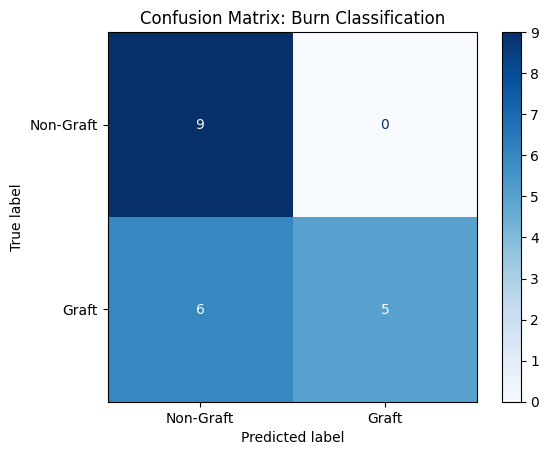


True Positives (Graft correctly identified): 5
True Negatives (Non-Graft correctly identified): 9
False Positives (Non-Graft mistaken for Graft): 0
False Negatives (Graft mistaken for Non-Graft): 6


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Generate Confusion Matrix using Test Labels and Predictions
cm = confusion_matrix(y_test_true, predictions, labels=["Non-Graft", "Graft"])

# Display the Matrix Visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Graft", "Graft"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Burn Classification")
plt.show()

# Print Raw values to match Table 1 in the paper
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives (Graft correctly identified): {tp}")
print(f"True Negatives (Non-Graft correctly identified): {tn}")
print(f"False Positives (Non-Graft mistaken for Graft): {fp}")
print(f"False Negatives (Graft mistaken for Non-Graft): {fn}")



```
# This is formatted as code
```

#### 📈 5. Feature Relevance Analysis
Analyzes SVM coefficients to identify which visual features most strongly influence the final graft or non-graft decision.

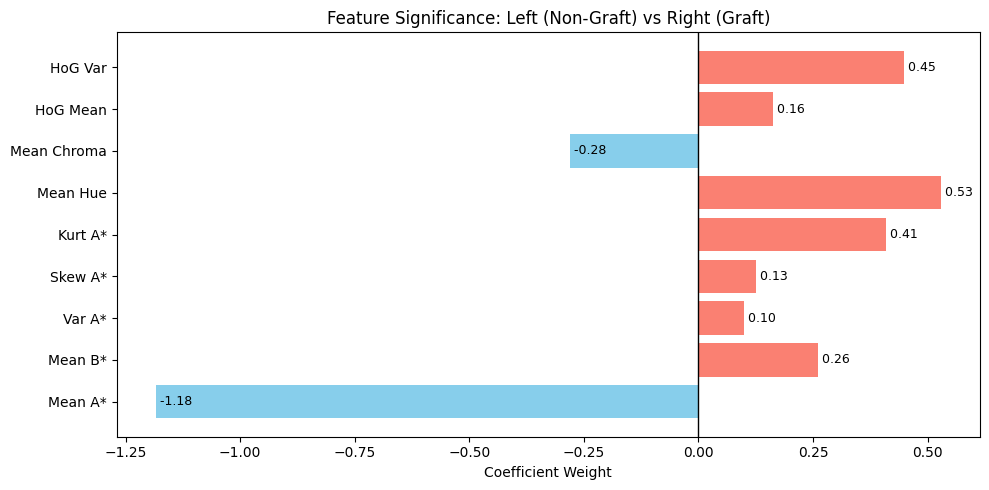

In [ ]:
import matplotlib.pyplot as plt

# Extract SVM weights
importances = svm_model.coef_[0]
feature_names = ['Mean A*', 'Mean B*', 'Var A*', 'Skew A*', 'Kurt A*', 'Mean Hue', 'Mean Chroma', 'HoG Mean', 'HoG Var']
colors = ['salmon' if val > 0 else 'skyblue' for val in importances]

plt.figure(figsize=(10, 5))
plt.barh(feature_names, importances, color=colors)
plt.axvline(0, color='black', linewidth=1)

# Minimal labels for class direction
plt.title("Feature Significance: Left (Non-Graft) vs Right (Graft)")
plt.xlabel("Coefficient Weight")

# Add value labels
for i, v in enumerate(importances):
    plt.text(v, i, f' {v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Modified

In [ ]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt

def estimate_skin_baseline(img_lab, percentile=60):
    """
    Estimate baseline skin chroma from the image.

    Instead of a fixed threshold, we sample the middle-chroma region
    of the image to approximate the patient's healthy skin tone.
    This makes the ROI mask skin-tone-relative rather than hardcoded,
    which is essential for accurate detection on darker skin.
    """

    #extracting the hue, chroma and ... features
    l_ch, a_ch, b_ch = cv2.split(img_lab)

    #completely because how openCV chooses to store data, it only stores between 0-255. Therefore
    #subtracting 128 would help us get the real CIELAB values
    a_float = a_ch.astype(float) - 128.0
    b_float = b_ch.astype(float) - 128.0
    chroma = np.sqrt(a_float**2 + b_float**2)

    # The background (e.g. dark surgical drape) has very low chroma.
    # Skin, regardless of tone, has moderate-to-high chroma compared to the background.

    #background has low chroma most of the time
    #the burnt region however always has significantly higher chroma compared to the background color
    # creating a true-false map of the whole image. find the pixels/points where
    # chroma > 5 (chroma>5--> wound, chroma<5-->background)
    skin_mask = chroma > 5
    #if no skin or noticable high chroma (which likely means no skin in the image), just flatten it
    if skin_mask.sum() == 0:
        return 15.0


    #assigning all the chosen pixels' chroma values
    skin_chroma = chroma[skin_mask]

    #the burn region will have varying chroma intensity
    #higher chroma values likely represent the more active parts of the burn
    #which will be extracted in the next step as ROI.
    #the 60th percentile captures the more stable part of the burn, which will make
    #it easier to identify the active regions during ROI extraction.
    return np.percentile(skin_chroma, percentile)


def extract_features(img_path, img_size=(256, 256)):


    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image: {img_path}")


    # using the cielab colorspace instead of the RGB for pixels on the image.
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

    l_channel, a_channel, b_channel = cv2.split(img_lab)

    # Centre A* and B* to their true zero (OpenCV stores LAB with 128 offset [0-255])
    a_float = a_channel.astype(float) - 128.0
    b_float = b_channel.astype(float) - 128.0
    # L* in OpenCV ranges 0-255; convert to standard 0-100 scale (the scale on the CIELAB space)
    l_float = l_channel.astype(float) / 2.55


    #there are images with significant variation in appearance, some are more vivid and some are
    #pale and faded out. a fixed threshold would miss burns with lower chroma values. By applying a
    #dynamic threshold value, which determined by the estimated skin baseline, we can make the ROI
    #extraction adapt to every case and more accurate.
    chroma = np.sqrt(a_float**2 + b_float**2)
    skin_baseline_chroma = estimate_skin_baseline(img_lab)
    #choose the values between for chroma = 8 and chroma*0.35
    #the threshold for being a more active burn
    dynamic_threshold = max(8.0, skin_baseline_chroma * 0.35)
    #if brighter than the dynamic threshhold, probably it's a more active part of the burn
    #, so add that to the ROI
    roi_mask = chroma > dynamic_threshold

    if roi_mask.sum() < 50:

        #lower the threshold if almost nothing is selected
        roi_mask = chroma > 5.0

    a_valid = a_float[roi_mask]
    b_valid = b_float[roi_mask]
    l_valid = l_float[roi_mask]


    mean_a   = np.mean(a_valid)
    mean_b   = np.mean(b_valid)
    var_a    = np.var(a_valid)
    skew_a   = skew(a_valid)
    kurt_a   = kurtosis(a_valid)

    #L* (lightness) statistics
    # L* captures the brightness/pallor changes that accompany deep burns,
    # and provides skin-tone context that A*/B* alone cannot encode.
    #nothing about the color, its just the BRIGHTNESS of the color
    #lightness pattern of the burn
    #when skin burns, it can potentially lose actual color, so color channels does not give
    #meaningful information, but l channel still changes significantly. Therefore, L channel was
    #a thing we had to consider
    mean_l   = np.mean(l_valid)
    var_l    = np.var(l_valid)
    skew_l   = skew(l_valid)

    #hue and chroma
    mean_hue    = np.arctan2(np.abs(mean_b), np.abs(mean_a) + 1e-5)
    mean_chroma = np.sqrt(mean_a**2 + mean_b**2)


    #HoG
    roi_mask_uint8 = roi_mask.astype(np.uint8) * 255
    img_roi_only   = cv2.bitwise_and(img_bgr, img_bgr, mask=roi_mask_uint8)
    img_resized    = cv2.resize(img_roi_only, img_size)

    fd       = hog(img_resized, orientations=8, pixels_per_cell=(16, 16),
                   cells_per_block=(1, 1), visualize=False, channel_axis=-1)
    hog_mean = np.mean(fd)
    hog_var  = np.var(fd)

    # we have parameters instead of 9
    # [mean_a, mean_b, var_a, skew_a, kurt_a,   <- original
    #  mean_l, var_l, skew_l,                    <- new, now more L* stats
    #  mean_hue, mean_chroma,                    <- original hue/chroma
    #  hog_mean, hog_var]                        <- original HoG
    return np.array([
        mean_a, mean_b, var_a, skew_a, kurt_a,
        mean_l, var_l, skew_l,
        mean_hue, mean_chroma,
        hog_mean, hog_var
    ])


FEATURE_NAMES = [
    'Mean A*', 'Mean B*', 'Var A*', 'Skew A*', 'Kurt A*',
    'Mean L*', 'Var L*', 'Skew L*',
    'Mean Hue', 'Mean Chroma',
    'HoG Mean', 'HoG Var'
]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/Penn State/NaiSS/NaiSS healthcare/Burns_BIP_US_database/training_set"
TEST_DIR  = "/content/drive/MyDrive/Penn State/NaiSS/NaiSS healthcare/Burns_BIP_US_database/testing_set"
TRAIN_EXT = ".jpg"
TEST_EXT  = ".bmp"

graft_labels = {21,22,23,24,29,30,33,34,35,36,37,38,40,45,47,48,49,50,51,
                58,59,60,61,62,64,65,66,67,68,69,70,74,75,76,77,78,79,80,81,82,83}

X_train, y_train = [], []

print("Extracting features from the training set...")
for i in range(21, 95):
    img_path = os.path.join(TRAIN_DIR, f"{i}{TRAIN_EXT}")
    if not os.path.exists(img_path):
        continue
    label = "Graft" if i in graft_labels else "Non-Graft"
    features = extract_features(img_path)
    X_train.append(features)
    y_train.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# ── OPTIMIZATION: RBF kernel + GridSearchCV instead of fixed linear C=0.5 ──
# Burn features are unlikely to be linearly separable. RBF handles
# non-linear boundaries. GridSearchCV with cross-validation finds the
# best C and gamma automatically and gives a more honest accuracy estimate.
param_grid = {
    'C':     [0.1, 0.5, 1, 5, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(SVC(), param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

svm_model   = grid_search.best_estimator_
best_params = grid_search.best_params_
cv_accuracy = grid_search.best_score_

print(f"Training complete. Trained on {len(X_train)} images.")
print(f"Best parameters: {best_params}")
print(f"Cross-validated accuracy: {cv_accuracy * 100:.2f}%")

Extracting features from the training set...
Training complete. Trained on 74 images.
Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Cross-validated accuracy: 85.24%


In [ ]:
# Labels for 21 test images
# "Superficial dermal"
# "Deep dermal"
# "Full-thickness"
test_labels_dict = {
    1: "Superficial dermal" ,2 : "Superficial dermal" , 3:"Superficial dermal", 4:"Superficial dermal", 5:"Superficial dermal",
    6:"Superficial dermal", 7:"Superficial dermal", 8:"Superficial dermal", 9:"Superficial dermal", 10:"Deep dermal",
    11:"Deep dermal", 12:"Deep dermal", 13:"Deep dermal", 14:"Deep dermal", 15:"Full-thickness", 16:"Full-thickness", 17:"Full-thickness",
    18:"Full-thickness", 19:"Full-thickness", 20:"Full-thickness", 21:"Full-thickness"
}

X_test = []
y_test_true = []

# Process the 21 test images
print("Extracting features from the testing set...")
for i in range(1,22):
    filename = f"{i}{TEST_EXT}"
    img_path = os.path.join(TEST_DIR, filename)

    if not os.path.exists(img_path):
        print(f"Missing: {img_path}")
        continue

    # Convert labels to binary classes: Non-Graft and Graft
    raw_label = test_labels_dict[i]
    binary_label = "Non-Graft" if raw_label == 'Superficial dermal' else "Graft"

    # Extract color and texture features (Hue, Chroma, Variance, Skewness, Kurtosis, HoG)
    # (Use your defined extraction model to extract the features)
    features = extract_features(img_path)
    X_test.append(features)
    y_test_true.append(binary_label)

X_test = np.array(X_test)

# Normalize features for consistent processing by the SVM
X_test_scaled = scaler.transform(X_test)

# Classify test images using the trained SVM model
predictions = svm_model.predict(X_test_scaled)

# Calculate and print Testing accuracy
accuracy = accuracy_score(y_test_true, predictions)
print(f"Testing complete. Tested on {len(X_test)} images.")
print(f"Overall Test Set Accuracy: {accuracy * 100:.2f}%\n")

Extracting features from the testing set...
Missing: /content/drive/MyDrive/Penn State/NaiSS/NaiSS healthcare/Burns_BIP_US_database/testing_set/21.bmp
Testing complete. Tested on 20 images.
Overall Test Set Accuracy: 95.00%



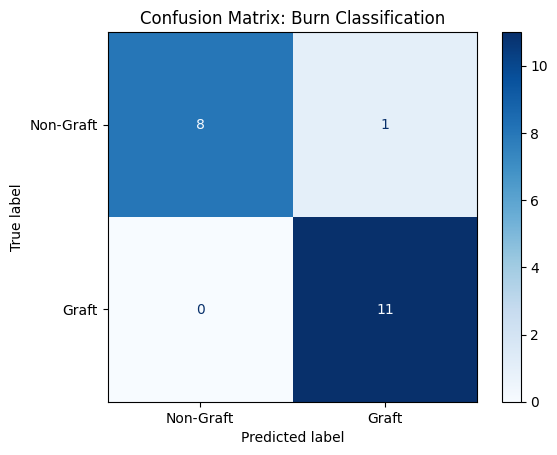


True Positives (Graft correctly identified): 11
True Negatives (Non-Graft correctly identified): 8
False Positives (Non-Graft mistaken for Graft): 1
False Negatives (Graft mistaken for Non-Graft): 0


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Generate Confusion Matrix using Test Labels and Predictions
cm = confusion_matrix(y_test_true, predictions, labels=["Non-Graft", "Graft"])

# Display the Matrix Visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Graft", "Graft"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Burn Classification")
plt.show()

# Print Raw values to match Table 1 in the paper
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives (Graft correctly identified): {tp}")
print(f"True Negatives (Non-Graft correctly identified): {tn}")
print(f"False Positives (Non-Graft mistaken for Graft): {fp}")
print(f"False Negatives (Graft mistaken for Non-Graft): {fn}")

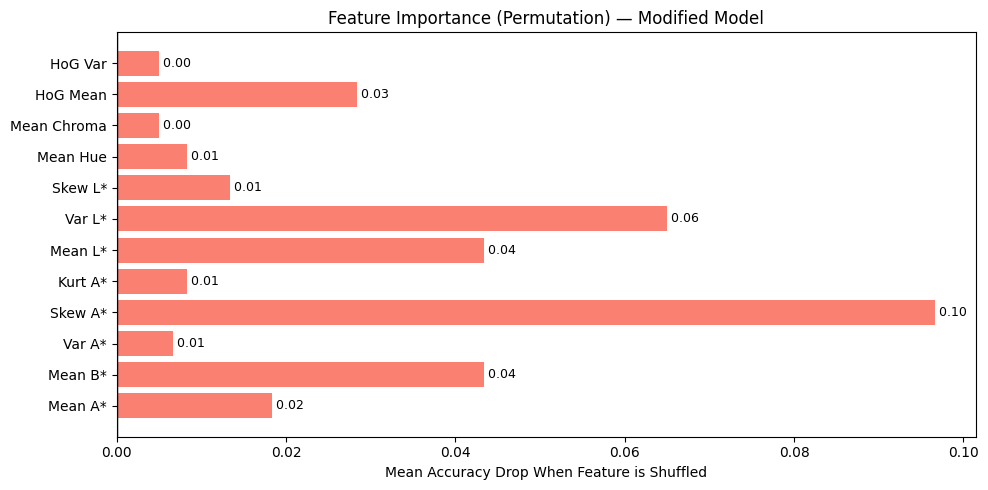

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

feature_names = [
    'Mean A*', 'Mean B*', 'Var A*', 'Skew A*', 'Kurt A*',
    'Mean L*', 'Var L*', 'Skew L*',
    'Mean Hue', 'Mean Chroma',
    'HoG Mean', 'HoG Var'
]

result = permutation_importance(svm_model, X_test_scaled, y_test_true,
                                n_repeats=30, random_state=42)

importances = result.importances_mean
colors = ['salmon' if val > 0 else 'skyblue' for val in importances]

plt.figure(figsize=(10, 5))
plt.barh(feature_names, importances, color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title("Feature Importance (Permutation) — Modified Model")
plt.xlabel("Mean Accuracy Drop When Feature is Shuffled")
for i, v in enumerate(importances):
    plt.text(v, i, f' {v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()